### Notebook for our Feed Forward Neural Network
This NN predicts which engagement-score quartile each post falls into, using the 29 engineered features from `feature_engineering.ipynb`. We report precision, recall, F1, and accuracy along with a test-set confusion matrix.

In [ ]:
import tensorflow as tf

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

/Users/neil/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/cz/1ztyq9fx3hq6vk03dptbj2mc0000gn/T/matplotlib-h0zg4ijc because there was an issue with the default path (/Users/neil/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
X_train = np.load('../data/features/X_train.npy')  
X_val   = np.load('../data/features/X_val.npy')    
X_test  = np.load('../data/features/X_test.npy')   

y_train_class  = np.load('../data/features/y_train.npy')   
y_val_class    = np.load('../data/features/y_val.npy')
y_test_class  = np.load('../data/features/y_test.npy')

idx_train    = np.load('../data/features/idx_train.npy') 
idx_val      = np.load('../data/features/idx_val.npy')
idx_test     = np.load('../data/features/idx_test.npy')

with open('../data/features/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

print('X_train shape:', X_train.shape)
print('Meta keys:', list(meta.keys()))

X_train shape: (31063, 29)
Meta keys: ['feature_index', 'label_map', 'label_map_inv', 'numeric_cols', 'scaler', 'seed', 'n_train', 'n_val', 'n_test', 'total_features']


In [3]:
df_raw = pd.read_parquet('../data/moltbook_posts_flat.parquet')
print('Dataframe shape:', df_raw.shape)
print('Columns labels:', df_raw.columns.tolist())

Dataframe shape: (44376, 14)
Columns labels: ['annotation_row_id', 'topic_label', 'toxic_level', 'post_id', 'title', 'content', 'created_at', 'comment_count', 'upvotes', 'downvotes', 'url', 'submolt_id', 'submolt_name', 'submolt_display_name']


In [4]:
def compute_engagement_score(df):
    upvotes  = df['upvotes'].clip(lower=0).fillna(0)
    downvotes = df['downvotes'].clip(lower=0).fillna(0)
    comments  = df['comment_count'].clip(lower=0).fillna(0)
    return (np.log( 1+ upvotes ) + np.log( 1+ comments ) - 0.5 * np.log( 1+ downvotes ))

engagement_all = compute_engagement_score(df_raw).values

y_train_score = engagement_all[idx_train]
y_val_score  = engagement_all[idx_val]
y_test_score = engagement_all[idx_test]

In [5]:
# Build quartile labels
quartile_edges = np.quantile(engagement_all, [0.25, 0.5, 0.75])

label_all = np.digitize(engagement_all, bins=quartile_edges, right=True)
y_train_quartile = label_all[idx_train]
y_val_quartile = label_all[idx_val]
y_test_quartile = label_all[idx_test]

print('Quartile cutoffs:', quartile_edges)
print('Train class counts:', np.bincount(y_train_quartile, minlength=4))
print('Val class counts:', np.bincount(y_val_quartile, minlength=4))
print('Test class counts:', np.bincount(y_test_quartile, minlength=4))

Quartile cutoffs: [0.34657359 1.38629436 2.48490665]
Train class counts: [7813 8055 7481 7714]
Val class counts: [1677 1723 1603 1653]
Test class counts: [1668 1733 1603 1653]


Epoch 1/50



  1/486 ━━━━━━━━━━━━━━━━━━━━ 3:05 382ms/step - accuracy: 0.3281 - loss: 1.3787


 79/486 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.4656 - loss: 1.1865  


167/486 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - accuracy: 0.4999 - loss: 1.1204


254/486 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.5164 - loss: 1.0869

...


Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



486/486 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.6487 - loss: 0.7836 - val_accuracy: 0.6352 - val_loss: 0.8152 - learning_rate: 2.5000e-04


Epoch 40: early stopping


Restoring model weights from the end of the best epoch: 32.


Test accuracy: 0.6302
Macro precision: 0.6334
Macro recall: 0.6300
Macro F1: 0.6215

Classification report:

              precision    recall  f1-score   support

           0     0.8479    0.7086    0.7720      1668
           1     0.5071    0.4916    0.4993      1733
           2     0.5468    0.4117    0.4698      1603
           3     0.6317    0.9080    0.7451      1653

    accuracy                         0.6302      6657
   macro avg     0.6334    0.6300    0.6215      6657
weighted avg     0.6330    0.6302    0.6216      6657



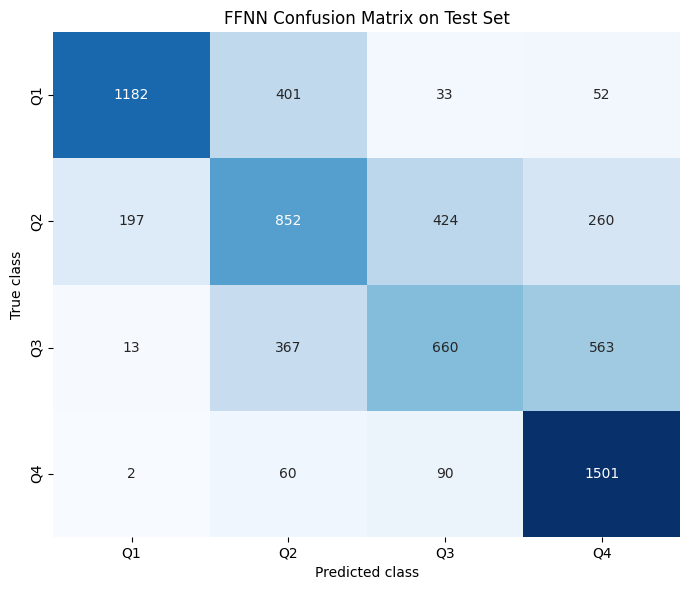

In [6]:
# Train tf.keras FFNN on quartile labels
np.random.seed(42)
tf.random.set_seed(42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train_scaled,
    y_train_quartile,
    validation_data=(X_val_scaled, y_val_quartile),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

test_prob = model.predict(X_test_scaled, verbose=0)
test_pred = np.argmax(test_prob, axis=1)

test_accuracy = accuracy_score(y_test_quartile, test_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test_quartile,
    test_pred,
    average='macro',
    zero_division=0,
)

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Macro precision: {macro_precision:.4f}')
print(f'Macro recall: {macro_recall:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification report:\n')
print(classification_report(y_test_quartile, test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test_quartile, test_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    yticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('FFNN Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

In [7]:
# Compare hidden-layer and activation combinations by running grid search over configurations
# Keep preprocessing in this section so it can be run independently

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

experiment_configs = [
    {"name": "relu_256_128", "hidden_layers": (256, 128), "activation": "relu", "dropout": 0.25},
    {"name": "relu_512_256", "hidden_layers": (512, 256), "activation": "relu", "dropout": 0.30},
    {"name": "tanh_256_128", "hidden_layers": (256, 128), "activation": "tanh", "dropout": 0.25},
    {"name": "tanh_512_256", "hidden_layers": (512, 256), "activation": "tanh", "dropout": 0.30},
    {"name": "elu_256_128", "hidden_layers": (256, 128), "activation": "elu", "dropout": 0.25},
    {"name": "elu_512_256", "hidden_layers": (512, 256), "activation": "elu", "dropout": 0.30},
]

def build_ffnn(input_dim, hidden_layers, activation, dropout):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation=activation))
        model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(4, activation='softmax'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

In [8]:
# Train each architecture in experiment_configs for up to 30 epochs with early
# stopping on val_loss, then score it on val and test. Seeds + clear_session
# at the top of every loop so the runs are comparable.
results = []

for cfg in experiment_configs:
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    model = build_ffnn(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout=cfg['dropout'],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=0,
        )
    ]

    history = model.fit(
        X_train_scaled,
        y_train_quartile,
        validation_data=(X_val_scaled, y_val_quartile),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=0,
    )

    val_prob = model.predict(X_val_scaled, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)

    test_prob = model.predict(X_test_scaled, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(y_val_quartile, val_pred)
    test_acc = accuracy_score(y_test_quartile, test_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test_quartile,
        test_pred,
        average='macro',
        zero_division=0,
    )

    results.append({
        'name': cfg['name'],
        'hidden_layers': str(cfg['hidden_layers']),
        'activation': cfg['activation'],
        'dropout': cfg['dropout'],
        'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'test_macro_precision': macro_precision,
        'test_macro_recall': macro_recall,
        'test_macro_f1': macro_f1,
    })

# Rank by macro F1, with test_accuracy as the tiebreaker.
results_df = pd.DataFrame(results).sort_values(
    by=['test_macro_f1', 'test_accuracy'],
    ascending=False,
).reset_index(drop=True)

print('Model comparison sorted by macro F1:')
display(results_df)

best_config = results_df.iloc[0]
print('\nBest configuration:')
print(best_config[['name', 'hidden_layers', 'activation', 'dropout', 'test_accuracy', 'test_macro_f1']])

Model comparison sorted by macro F1:


,name,hidden_layers,activation,dropout,best_epoch,val_accuracy,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,relu_512_256,"(512, 256)",relu,0.30,19,0.630108,0.628211,0.637845,0.627865,0.621345
1,relu_256_128,"(256, 128)",relu,0.25,25,0.634615,0.626559,0.632065,0.626937,0.619790
2,tanh_512_256,"(512, 256)",tanh,0.30,26,0.633714,0.627460,0.644042,0.626159,0.619176
3,tanh_256_128,"(256, 128)",tanh,0.25,27,0.632061,0.623704,0.641336,0.622721,0.618803
4,elu_256_128,"(256, 128)",elu,0.25,30,0.613582,0.616494,0.639643,0.615857,0.613213
5,elu_512_256,"(512, 256)",elu,0.30,30,0.608924,0.609584,0.615539,0.610060,0.600500



Best configuration:
name             relu_512_256
hidden_layers      (512, 256)
activation               relu
dropout                   0.3
test_accuracy        0.628211
test_macro_f1        0.621345
Name: 0, dtype: object


Retraining best config:
{'hidden_layers': (512, 256), 'activation': 'relu', 'dropout': 0.3}
Epoch 1/80



  1/486 ━━━━━━━━━━━━━━━━━━━━ 2:48 348ms/step - accuracy: 0.3125 - loss: 1.3851


 24/486 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4248 - loss: 1.2843    


 50/486 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4708 - loss: 1.2025


 77/486 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4933 - loss: 1.1557

...


Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6589 - loss: 0.7672 - val_accuracy: 0.6282 - val_loss: 0.8233 - learning_rate: 2.5000e-04


Epoch 37: early stopping


Restoring model weights from the end of the best epoch: 27.


Test accuracy: 0.6263
Macro precision: 0.6306
Macro recall: 0.6261
Macro F1: 0.6178


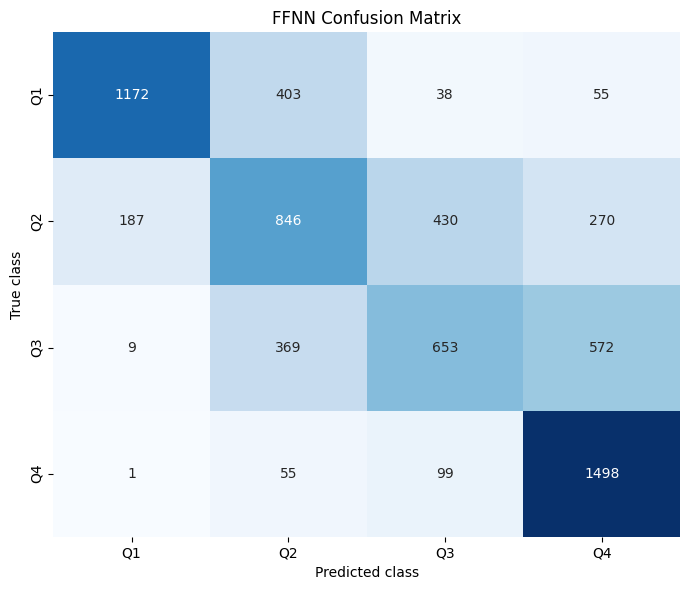

In [9]:
# Retrain the best architecture for longer and plot its confusion matrix

if 'best_config' not in globals():
    raise ValueError('Run the model-comparison cell first so best_config is available.')

best_hidden_layers = tuple(int(x.strip()) for x in best_config['hidden_layers'].strip('()').split(','))
best_activation = best_config['activation']
best_dropout = float(best_config['dropout'])

print('Retraining best config:')
print({'hidden_layers': best_hidden_layers, 'activation': best_activation, 'dropout': best_dropout})

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

best_model = build_ffnn(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=best_hidden_layers,
    activation=best_activation,
    dropout=best_dropout,
)

long_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

long_history = best_model.fit(
    X_train_scaled,
    y_train_quartile,
    validation_data=(X_val_scaled, y_val_quartile),
    epochs=80,
    batch_size=64,
    callbacks=long_callbacks,
    verbose=1,
)

best_test_prob = best_model.predict(X_test_scaled, verbose=0)
best_test_pred = np.argmax(best_test_prob, axis=1)

best_test_acc = accuracy_score(y_test_quartile, best_test_pred)
best_macro_precision, best_macro_recall, best_macro_f1, _ = precision_recall_fscore_support(
    y_test_quartile,
    best_test_pred,
    average='macro',
    zero_division=0,
)

print(f'Test accuracy: {best_test_acc:.4f}')
print(f'Macro precision: {best_macro_precision:.4f}')
print(f'Macro recall: {best_macro_recall:.4f}')
print(f'Macro F1: {best_macro_f1:.4f}')

best_cm = confusion_matrix(y_test_quartile, best_test_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 6))
sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    yticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('FFNN Confusion Matrix')
plt.tight_layout()
plt.show()

In [10]:
# Per-quartile accuracy on the test split.

if 'best_test_pred' in globals():
    pred_for_quartile_acc = best_test_pred
    model_tag = 'Best Config FFNN'
elif 'test_pred' in globals():
    pred_for_quartile_acc = test_pred
    model_tag = 'Baseline FFNN'
else:
    raise ValueError('Run a training/evaluation cell first so predictions are available.')

quartile_labels = [0, 1, 2, 3]
quartile_names = ['Q1', 'Q2', 'Q3', 'Q4']

print(f'Per-quartile accuracy ({model_tag}):')
for q_label, q_name in zip(quartile_labels, quartile_names):
    mask = (y_test_quartile == q_label)
    if np.sum(mask) == 0:
        print(f'{q_name}: N/A (no samples in this quartile)')
    else:
        q_acc = np.mean(pred_for_quartile_acc[mask] == y_test_quartile[mask])
        print(f'{q_name}: {q_acc:.4f} ({q_acc * 100:.2f}%)')

Per-quartile accuracy (Best Config FFNN):
Q1: 0.7026 (70.26%)
Q2: 0.4882 (48.82%)
Q3: 0.4074 (40.74%)
Q4: 0.9062 (90.62%)
